# 05 — User Segmentation

**Project:** E-Commerce User Behavior Analysis & Recommendation System  
**Notebook purpose:** Segment the 5.3M users into meaningful behavioral groups using unsupervised clustering. Cluster labels are saved as `user_segments.parquet` for use in all downstream notebooks.

---

## Environment Setup

This notebook was run on **Kaggle Notebooks** using the feature table produced by `04_feature_engineering.ipynb`.

### To reproduce this notebook

1. Go to the repository on GitHub:  
   [ecommerce-behavior-analysis](https://github.com/halleepham/ecommerce-behavior-analysis)
2. Download `notebooks/05_user_segmentation.ipynb`
3. Open a Kaggle notebook and attach the output dataset from `04_feature_engineering.ipynb` as an input **OR** email kylenaluan@gmail.com to request access to the private kaggle dataset 'kylenaluan/user-features/user_features.parquetkylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet'
4. Run all cells top to bottom

### Data path

All cells in this notebook use the following path to access the user features:

    /kaggle/input/datasets/kylenaluan/user-features

### Python version and key libraries

| Library | Version |
|---|---|
| Python | 3.12.12 |
| pandas | 2.3.3 |
| numpy | 2.0.2 |
| scikit-learn | 1.6.1 |
| pyplot | 3.10.0 |
| seaborn | 0.13.2 |

---

## Scope

This notebook loads `user_features.parquet` (5,316,649 users × 11 features) and applies unsupervised clustering to group users by behavioral patterns. The workflow is:

| Section | Description |
|---|---|
| 1. Setup & Data Loading | Install dependencies, import libraries, load and inspect `user_features.parquet` |
| 2. Feature Selection & Preprocessing | Select numeric clustering features, transform skewed data, standardize with `StandardScaler` |
| 3. Choosing k (Elbow + Silhouette) | Run K-Means over a range of k values on a sample; plot inertia and silhouette scores |
| 4. K-Means Clustering | Fit final K-Means model on full user set with chosen k; assign cluster labels |
| 5. Dimensionality Reduction & Visualization | Reduce to 2D with PCA and plot clusters |
| 6. Cluster Profiling | Compute per-cluster feature medians; assign descriptive labels; visualize with bar charts |
| 7. Save Output | Write `user_segments.parquet` with `user_id`, `cluster_id`, and `cluster_label` |

**Output:** `user_segments.parquet`

---

## 1. Setup & Data Loading

In [1]:
%pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Paths
FEATURES_FILE = '/kaggle/input/datasets/kylenaluan/user-features'
OUTPUT_DIR    = '/kaggle/working'

# Constants
SEED = 5530
MAX_K = 10
K_RANGE = range(2, 11)

print(f'File exists  : {os.path.exists(FEATURES_FILE)}')
print(f'Python       : {sys.version}')
print(f'pandas       : {pd.__version__}')
print(f'numpy        : {np.__version__}')
print(f'scikit-learn : {sklearn.__version__}')
print(f'pyplot       : {plt.matplotlib.__version__}')
print(f'seaborn      : {sns.__version__}')

File exists  : True
Python       : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas       : 2.3.3
numpy        : 2.0.2
scikit-learn : 1.6.1
pyplot       : 3.10.0
seaborn      : 0.13.2


In [3]:
# Load user features
df = pd.read_parquet(FEATURES_FILE)
print('Shape:', df.shape)
df.head(5)

Shape: (5316649, 11)


,n_carts,n_purchases,n_views,recency_days,total_spend,active_days,preferred_category,preferred_brand,conversion_rate,cart_abandonment_rate,avg_spend_per_purchase
user_id,,,,,,,,,,,
10300217,0,0,1,24.713970,0.0,1,unknown,sokolov,0.0,1.0,0.0
29515875,0,0,11,10.333542,0.0,3,furniture,harper,0.0,1.0,0.0
31198833,0,0,20,11.932303,0.0,4,electronics,xiaomi,0.0,1.0,0.0
33869381,0,0,1,38.163785,0.0,1,kids,bumbleride,0.0,1.0,0.0
34916060,0,0,1,6.678079,0.0,1,appliances,tefal,0.0,1.0,0.0


In [4]:
# Inspect dtypes and missing values
print('--- dtypes ---')
print(df.dtypes)
print('\n--- Missing values ---')
print(df.isnull().sum())

--- dtypes ---
n_carts                     int64
n_purchases                 int64
n_views                     int64
recency_days              float64
total_spend               float32
active_days                 int64
preferred_category         object
preferred_brand            object
conversion_rate           float64
cart_abandonment_rate     float64
avg_spend_per_purchase    float64
dtype: object

--- Missing values ---
n_carts                        0
n_purchases                    0
n_views                        0
recency_days                   0
total_spend                    0
active_days                    0
preferred_category           521
preferred_brand           270157
conversion_rate                0
cart_abandonment_rate          0
avg_spend_per_purchase         0
dtype: int64


In [5]:
# Check skew of each numeric column
print('Original Data Skew:')
print(df.skew(numeric_only=True))

Original Data Skew:
n_carts                   19.882071
n_purchases               48.014047
n_views                   36.839779
recency_days               0.622130
total_spend               84.690887
active_days                3.945092
conversion_rate            7.460502
cart_abandonment_rate     -3.383913
avg_spend_per_purchase     6.299687
dtype: float64


In [6]:
# Check unique values in categorical data
print(f'Unique Categories: {df['preferred_category'].nunique()}')
print(f'Unique Brands    : {df['preferred_brand'].nunique()}')

Unique Categories: 14
Unique Brands    : 3805


---

## 2. Feature Selection & Preprocessing

The following numeric features are used for clustering:

| Feature | Rationale |
|---|---|
| `recency_days` | How recently the user was active |
| `n_views` | Overall engagement volume |
| `n_carts` | Cart interaction frequency |
| `n_purchases` | Purchase frequency |
| `total_spend` | Monetary value |
| `active_days` | Breadth of engagement over time |
| `conversion_rate` | Efficiency of browsing → buying |
| `cart_abandonment_rate` | Tendency to abandon carts |
| `avg_spend_per_purchase` | Average order value |

`preferred_category` and `preferred_brand` are not used in clustering.
* K-means works on numeric data
* These columns could be encoded, but since they have many unique values there would be very high dimensionality.
* They are not necessary for clustering since we want to divide users into segments based on behavior and how they interact with the store.

**Preprocessing steps:**
1. **Log1p transform** on right-skewed features
2. **Cube transform** on left-skewed features
3. **StandardScaler** to bring all features to the same scale before computing distances

In [7]:
CLUSTER_FEATURES = [
    'recency_days',
    'n_views',
    'n_carts',
    'n_purchases',
    'total_spend',
    'active_days',
    'conversion_rate',
    'cart_abandonment_rate',
    'avg_spend_per_purchase'
]

LOG_FEATURES = [
    'n_views',
    'n_carts',
    'n_purchases',
    'total_spend',
    'active_days',
    'conversion_rate',
    'avg_spend_per_purchase'
]

# Extract and copy clustering features
X = df[CLUSTER_FEATURES].copy()

# Log1p transform right-skewed features
for col in LOG_FEATURES:
    X[col] = np.log1p(X[col])

# Cube left-skewed features
X['cart_abandonment_rate'] = np.power(X['cart_abandonment_rate'], 3)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Processed feature matrix shape:', X_scaled.shape)

Processed feature matrix shape: (5316649, 9)


In [8]:
print('Transformed Data Skew:')
print (X.skew())

Transformed Data Skew:
recency_days              0.622130
n_views                   0.802547
n_carts                   2.585445
n_purchases               3.615998
total_spend               2.452850
active_days               1.370956
conversion_rate           6.142730
cart_abandonment_rate    -2.779644
avg_spend_per_purchase    2.379019
dtype: float64


In [9]:
skew_dif = df.select_dtypes(include=np.number).skew() - X.skew()

print('Difference in skew (original - transformed)')
print(skew_dif[CLUSTER_FEATURES])

Difference in skew (original - transformed)
recency_days               0.000000
n_views                   36.037232
n_carts                   17.296626
n_purchases               44.398049
total_spend               82.238037
active_days                2.574136
conversion_rate            1.317772
cart_abandonment_rate     -0.604269
avg_spend_per_purchase     3.920668
dtype: float64


---

## 3. Choosing k — Elbow Method & Silhouette Score

K-Means is fit on a random sample of 500,000 users rather than the entire dataset. Models of different k (clusters) are fit and evaluated using the following metrics:

- **Inertia (elbow):** Measures inertia, the within-cluster sum of squares. This is the sum of squared distances from each datapoint to its assigned cluster center. We will look for the "elbow" where improvement flattens.
- **Silhouette score:** Measures how similar data points are to their own cluster compared to other clusters. Scores range from [-1,1].
  - +1 - A point is well placed in its cluster
  - 0 - A point is on a boundary between clusters
  - -1 - A point is in the wrong cluster

A final k will be chosen based on this evaluation and a model with k clusters will be fit over the entire dataset.

In [10]:
# Sample for k-selection step
SAMPLE_SIZE  = 500_000

np.random.seed(SEED)
sample_idx  = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample    = X_scaled[sample_idx]

print(f'Sample size: {X_sample.shape}')

Sample size: (500000, 9)


In [11]:
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=50_000, random_state=SEED))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

k=2  inertia=2,246,953  silhouette=0.6571
k=3  inertia=1,719,793  silhouette=0.3955
k=4  inertia=1,448,197  silhouette=0.3942
k=5  inertia=1,192,924  silhouette=0.3657
k=6  inertia=1,067,211  silhouette=0.3718
k=7  inertia=966,438  silhouette=0.3698
k=8  inertia=869,689  silhouette=0.3725
k=9  inertia=805,829  silhouette=0.3551
k=10  inertia=760,967  silhouette=0.2890


In [12]:
k_diff_labels = []

for k in range(2, MAX_K):
    k_diff_labels.append(f'{k} -> {k+1}')

print('Inertia Decreases for Increasing K:')
inertia_diffs = pd.DataFrame(columns=['k','difference'])
inertia_diffs['k'] = k_diff_labels
inertia_diffs['difference'] = np.diff(inertias)

inertia_diffs.style.hide(axis='index')

Inertia Decreases for Increasing K:


k,difference
2 -> 3,-527159.722894
3 -> 4,-271595.569123
4 -> 5,-255273.283580
5 -> 6,-125712.775770
6 -> 7,-100773.226434
7 -> 8,-96748.783031
8 -> 9,-63860.227113
9 -> 10,-44862.437417


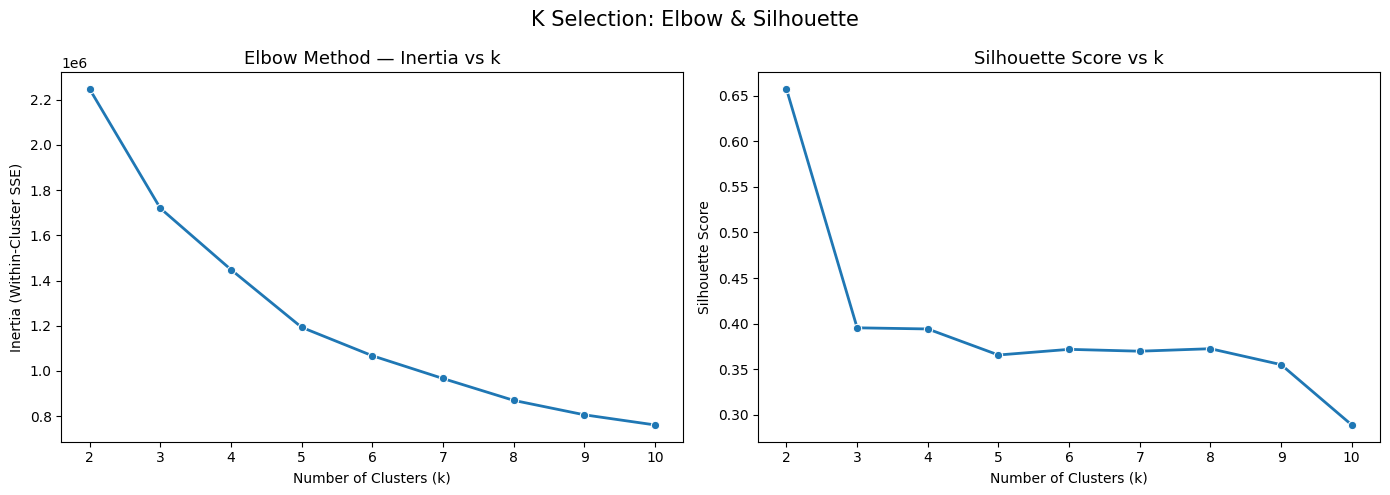

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
sns.lineplot(x=list(K_RANGE), y=inertias, marker='o', linewidth=2, ax=axes[0])
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')

# Silhouette plot
sns.lineplot(x=list(K_RANGE), y=sil_scores, marker='o', linewidth=2, ax=axes[1])
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('K Selection: Elbow & Silhouette', fontsize=15)
plt.tight_layout()
plt.savefig('k_selection.png', bbox_inches='tight')
plt.show()

* No clear 'elbow' where inertia starts decreasing with minimal improvement.
* `k=2` has the highest silhouette score, however choosing 2 clusters would provide us little information in this context. It would likely just separate the users into those who purchased items and those who did not.
* Inertia decrease is high between `k=2` to `k=3` (~571k) and falls to ~271k between `k=3` to `k=4`
  * Inertia decrease is similar between `k=4` to `k=5` (~255k)
  * Improvement in intertia falls off heavily after `k=4` and `k=5`
    * This is where I believe any 'elbow' would be
* Comparing silhouette scores, `k=5` is less suitable than `k=4` as it has a lower silhouette score.
* `k=3` and `k=4` have very similar silhouette scores, however in the elbow plot, inertia improvement remains steep (a similar rate as after `k=3`) after `k=4`.
* For these reasons **`k=4`** is chosen to fit the final model.

---

## 4. K-Means Clustering

Set `K` below based on the elbow and silhouette plots above, then fit the final model on all 5.3M users.

In [14]:
# ── Set this after inspecting the plots above ──
K = 4

km_final = KMeans(n_clusters=K, n_init=10, random_state=SEED)
cluster_labels = km_final.fit_predict(X_scaled)

df['cluster_id'] = cluster_labels

print('Cluster distribution:')
print(df['cluster_id'].value_counts().sort_index())

Cluster distribution:
cluster_id
0    3291223
1     170343
2    1359678
3     495405
Name: count, dtype: int64


---

## 5. Dimensionality Reduction & Visualization

There are 9 features that were used for clustering, which is too many to plot on a 2d graph. To visualize our clusters, we can use a dimension-reduction method to reduce the number of components to 2:

- **PCA** — Reduces number of features in a dataset while keeping important information (using linear algebra). Transforms correlated features into a smaller set of uncorrelated components (principal components).

A subsample of 50,000 users is taken to speed up visualization time.

In [15]:
# Use a subsample for visualization
VIZ_SIZE = 50_000
viz_idx  = np.random.choice(len(X_scaled), size=VIZ_SIZE, replace=False)
X_viz    = X_scaled[viz_idx]
labels_viz = cluster_labels[viz_idx]

# PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_viz)

print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}')

PCA variance explained: 76.99%


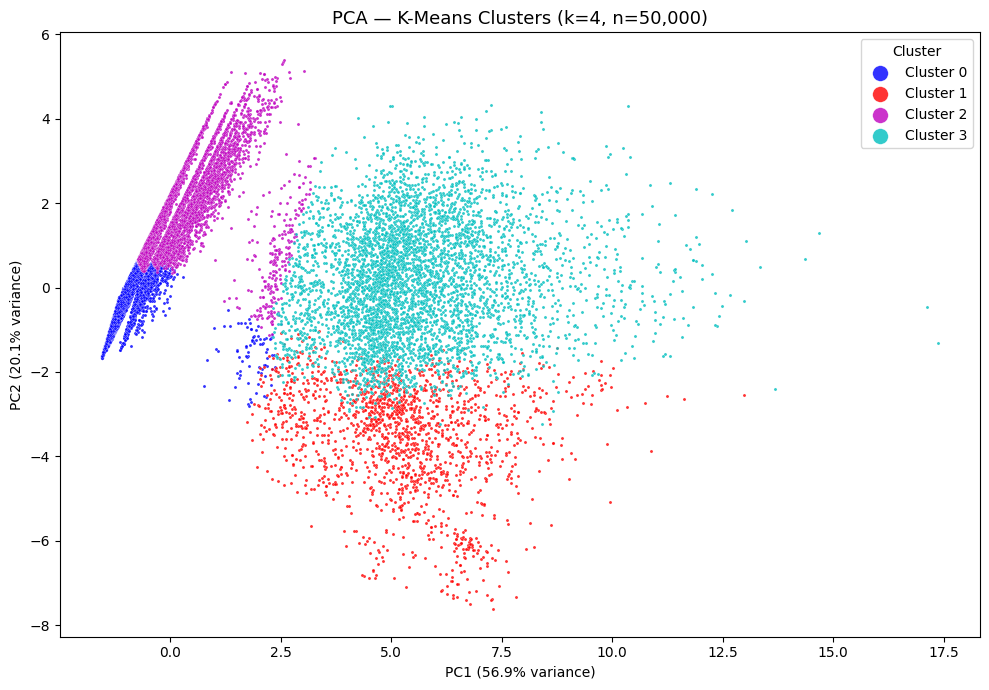

In [16]:
palette = {0: 'b', 1: 'r', 2: 'm', 3: 'c'}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in sorted(np.unique(labels_viz)):
    mask = labels_viz == cluster_id
    sns.scatterplot(
        x=X_pca[mask, 0],
        y=X_pca[mask, 1],
        color=palette[cluster_id],
        label=f'Cluster {cluster_id}',
        s=5,
        alpha=0.8,
        ax=ax
    )

ax.set_title(f'PCA — K-Means Clusters (k={K}, n={VIZ_SIZE:,})', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(title='Cluster', markerscale=5)
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

The clusters appear to be fairly well separated. There is slight overlap between clusters 1 and 3, and some users from the large, main cluster on the right are classified as belonging to clusters 0 and 2. Overall, there seems to be a good distinction between clusters.

* Almost 77% of the information from the original features is captured by the PCA - This is a good amount, so the PCA plot is fairly representative.
  * 56.9% of the variance in the data is captured by the 1st principal component
  * 20.1% of the variance is captured by the 2nd principal component

---

## 6. Cluster Profiling

For each cluster we compute the median of every numeric feature. Medians are used over means because of the skew caused by outliers in some of the features. Medians are more robust to outliers within a cluster.

After reviewing the profiles we assign a descriptive label to each cluster.

In [17]:
# Compute cluster profiles on original features
PROFILE_FEATURES = [
    'recency_days', 'n_views', 'n_carts', 'n_purchases',
    'total_spend', 'active_days', 'conversion_rate',
    'cart_abandonment_rate', 'avg_spend_per_purchase',
]

profile = (
    df[PROFILE_FEATURES + ['cluster_id']]
    .groupby('cluster_id')
    .median()
    .round(3)
)

print('--- Cluster Profiles (median) ---')
profile

--- Cluster Profiles (median) ---


,recency_days,n_views,n_carts,n_purchases,total_spend,active_days,conversion_rate,cart_abandonment_rate,avg_spend_per_purchase
cluster_id,,,,,,,,,
0,25.572,2.0,0.0,0.0,0.000000,1.0,0.000,1.000,0.00
1,23.633,4.0,1.0,1.0,283.100006,1.0,0.333,0.222,207.96
2,9.045,23.0,0.0,0.0,0.000000,4.0,0.000,1.000,0.00
3,9.361,42.0,3.0,1.0,272.920013,6.0,0.043,0.500,172.22


From the cluster statistics, we can assign the following labels:

| Label | Description |
|---|---|
| Passive Browsers | Low counts across all features, high `recency_days` |
| One Time Buyers | Low `n_views`, low `n_purchases` (≈1), non-zero `total_spend`, high `recency_days` |
| Active Browsers (no purchase) | High `n_views`, low `n_purchases`, high `cart_abandonment_rate`, low `recency_days` |
| Engaged Buyers | High `n_views`, non-zero `n_purchases`, non-zero `total_spend`, low `recency_days` |

In [18]:
# Assign cluster labels
CLUSTER_LABELS = {
    0: 'Passive Browsers',
    1: 'One Time Buyers',
    2: 'Active Browsers',
    3: 'Engaged Buyers'
}

df['cluster_label'] = df['cluster_id'].map(CLUSTER_LABELS)
print(df['cluster_label'].value_counts())

cluster_label
Passive Browsers    3291223
Active Browsers     1359678
Engaged Buyers       495405
One Time Buyers      170343
Name: count, dtype: int64


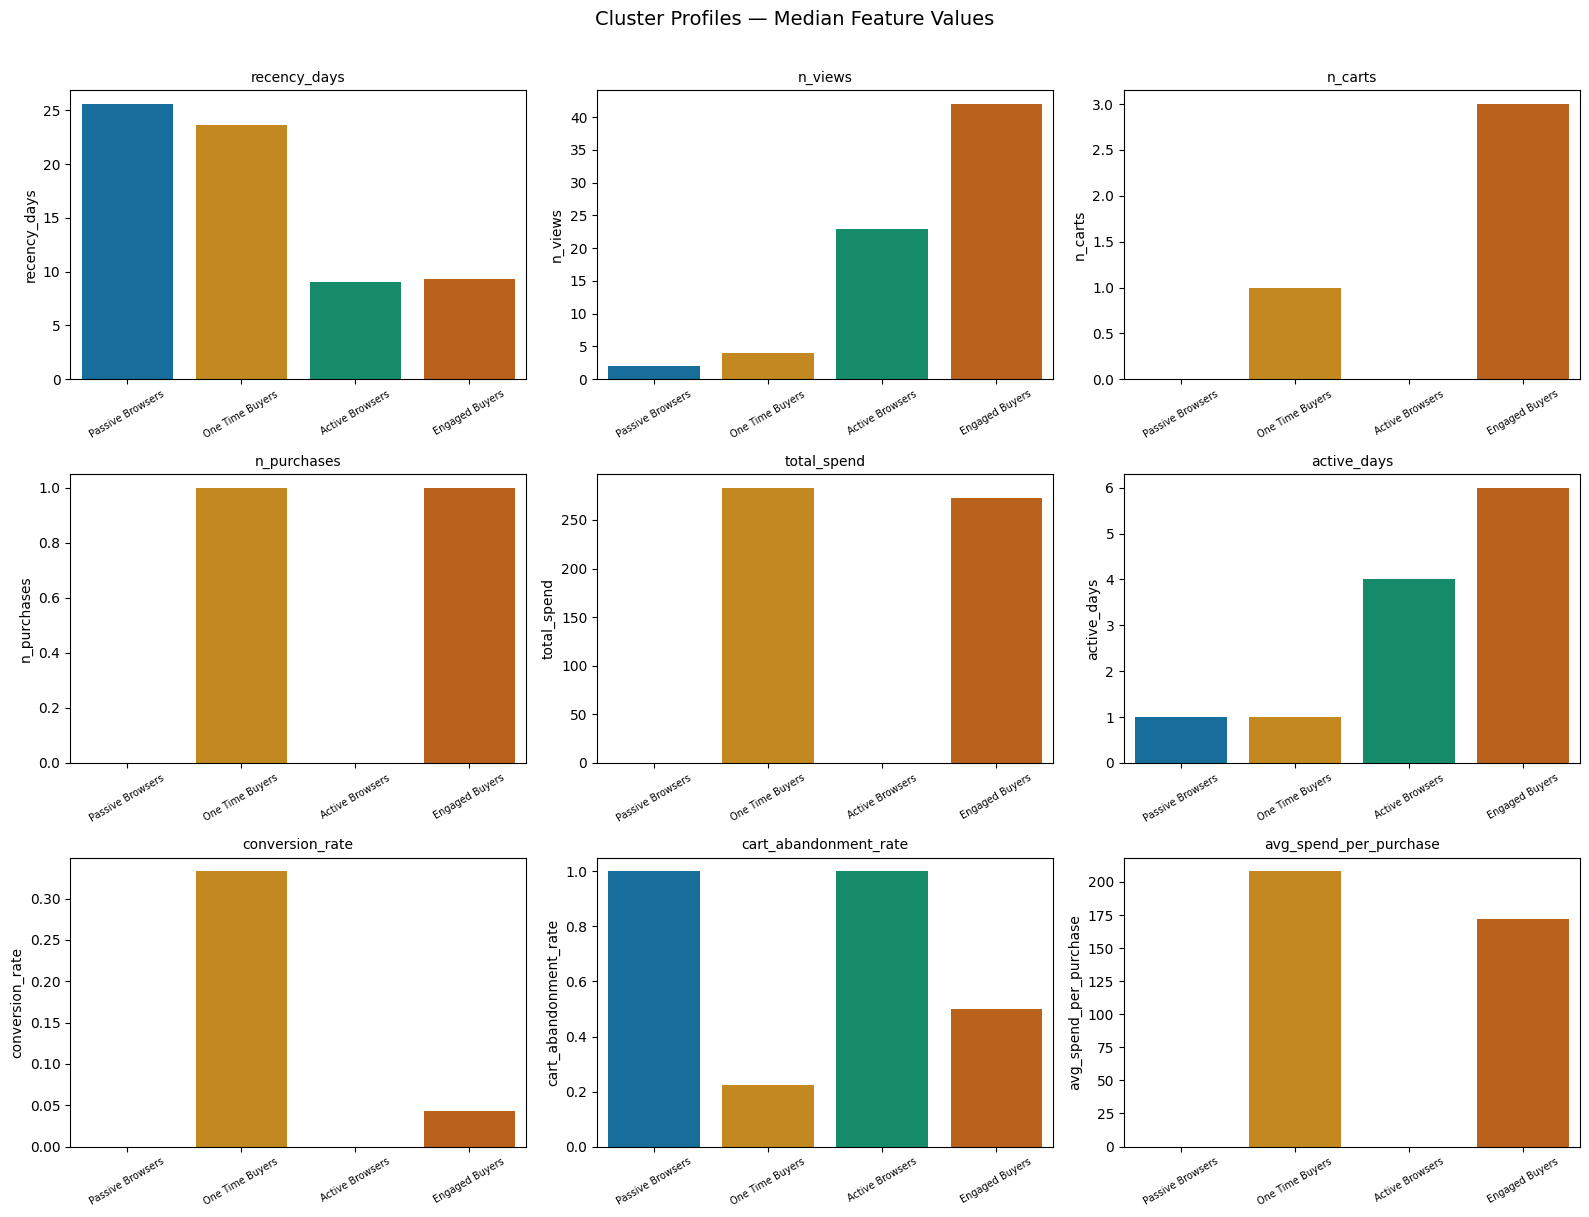

In [19]:
# Bar charts: median feature values by cluster
profile_plot = profile.copy()
profile_plot.index = profile_plot.index.map(CLUSTER_LABELS)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(PROFILE_FEATURES):
    sns.barplot(
        x=profile_plot.index,
        y=profile_plot[feat],
        palette='colorblind',
        ax=axes[i]
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Cluster Profiles — Median Feature Values', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('cluster_profiles.png', bbox_inches='tight')
plt.show()

In [20]:
# Top preferred categories per cluster
cat_dist = (
    df.groupby(['cluster_label', 'preferred_category'])
    .size()
    .reset_index(name='count')
    .sort_values(['cluster_label', 'count'], ascending=[True, False])
    .groupby('cluster_label')
    .head(5)
)
cat_dist.style.hide(axis='index')

cluster_label,preferred_category,count
Active Browsers,electronics,546900
Active Browsers,unknown,461319
Active Browsers,appliances,151484
Active Browsers,computers,68289
Active Browsers,apparel,46588
Engaged Buyers,electronics,230328
Engaged Buyers,unknown,155376
Engaged Buyers,appliances,55594
Engaged Buyers,computers,20061
Engaged Buyers,apparel,10466


The top categories are the same for each cluster. In hindsight, it appears that including `preferred_categories` in the clustering features would not have provided much information anyways.

---

## 7. Save Output

In [21]:
# Save user_segments.parquet
user_segments = df[['cluster_id', 'cluster_label']].copy()
user_segments.index.name = 'user_id'

out_path = f'{OUTPUT_DIR}/user_segments.parquet'
user_segments.to_parquet(out_path, engine='fastparquet', compression='snappy')

print('User segments saved:', user_segments.shape)
user_segments.head(5)

User segments saved: (5316649, 2)


,cluster_id,cluster_label
user_id,,
10300217,0,Passive Browsers
29515875,2,Active Browsers
31198833,2,Active Browsers
33869381,0,Passive Browsers
34916060,0,Passive Browsers
